# Candelaria Vial: priorización preventiva con datos abiertos

**Asignatura:** Técnicas de Aprendizaje de Máquina  
**Integrantes:** Completar nombres y códigos  
**Fuente principal:** [Accidentalidad Vial Municipio de Candelaria, Valle](https://www.datos.gov.co/Transporte/Accidentalidad-Vial-Municipio-de-Candelaria-Valle-/7wbf-88zm)

> **Nota de reproducibilidad.** Ejecutar el cuaderno de arriba hacia abajo y anotar la fecha de descarga: el conjunto abierto puede actualizarse.

## 1. El problema que queremos resolver

Como equipo queremos apoyar una decisión concreta: **en qué corregimientos conviene revisar primero las condiciones de seguridad vial durante el próximo mes**. La Secretaría de Tránsito y Transporte de Candelaria tiene recursos limitados; por eso no basta con mirar el último accidente o decidir únicamente por intuición.

Trabajamos con registros históricos de siniestros y respondemos dos preguntas a nivel de **corregimiento-mes**:

1. **Regresión:** ¿cuántos siniestros se esperan el próximo mes en cada corregimiento?
2. **Clasificación:** ¿ese corregimiento-mes puede entrar en una categoría de alta siniestralidad?

**Stakeholder:** Secretaría de Tránsito y Transporte de Candelaria, Valle del Cauca.  
**Qué haría con el resultado:** priorizar inspecciones, señalización, campañas y validación de campo.  
**Qué no haría con el resultado:** sancionar personas, atribuir culpa o afirmar que un lugar es “peligroso” por naturaleza.

### Hipótesis que vamos a contrastar

1. Los registros mensuales no se distribuyen igual entre los corregimientos.
2. La actividad reciente de un corregimiento aporta información para el siguiente mes.
3. Los lags y el calendario superan una regla básica que asigna el mismo promedio histórico a todos los corregimientos.

Nuestro criterio no es usar ML por obligación: si no supera una referencia simple en una prueba temporal, lo correcto sería recomendar un tablero descriptivo.

## 2. Revisión crítica con IA: definición del problema

Usamos IA para cuestionar el planteamiento, no para reemplazar nuestro análisis.

**Prompt usado:**

> Actúa como directora de movilidad de Candelaria. Queremos priorizar intervenciones de seguridad vial con registros históricos y responder dos preguntas por corregimiento-mes: cuántos siniestros se esperan el próximo mes y si ese mes tendrá alta siniestralidad. Dame razones concretas para no financiar el proyecto, qué evidencia pedirías y qué daño podría causar un falso positivo o falso negativo.

**Qué nos hizo revisar esa crítica:** el conjunto puede tener subregistro y cambios administrativos; una frecuencia alta no demuestra una causa; y una alerta puede concentrar recursos en zonas que ya tienen mayor vigilancia.

**Decisiones que tomamos:** dejamos el último año para prueba, construimos un panel que incluye meses con cero siniestros, usamos únicamente variables disponibles antes del mes objetivo y planteamos la app como apoyo a una inspección humana, nunca como mecanismo sancionatorio.

In [ ]:
!pip -q install pandas numpy scikit-learn seaborn plotly

import warnings
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score, average_precision_score, confusion_matrix, f1_score,
    mean_absolute_error, mean_squared_error, precision_score, r2_score,
    recall_score, roc_auc_score, RocCurveDisplay, PrecisionRecallDisplay,
)
from sklearn.model_selection import ParameterSampler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
RANDOM_STATE = 42
DATA_URL = "https://www.datos.gov.co/resource/7wbf-88zm.csv?$limit=100000"
DOWNLOAD_TIME = datetime.now(timezone.utc).isoformat()

zsh:1: command not found: pip


In [ ]:
raw = pd.read_csv(DATA_URL)
expected_columns = {
    "clase_de_accidente", "gravedad", "vias", "corregimiento",
    "d_a_semana", "fecha_de_ocurrecia", "hora_ocurrencia",
}
assert expected_columns.issubset(raw.columns), "El esquema publicado cambió; revisar el diccionario."
print(f"Fecha UTC de descarga: {DOWNLOAD_TIME}")
print(f"Filas: {len(raw):,}; columnas: {raw.shape[1]}")
raw.head()

Fecha UTC de descarga: 2026-09-18T19:16:34.901796+00:00
Filas: 1,208; columnas: 7


,clase_de_accidente,gravedad,vias,corregimiento,d_a_semana,fecha_de_ocurrecia,hora_ocurrencia
0,CHOQUE,DAÑOS,CALI-CANDELARIA,VILLAGORGONA,VIERNES,1/01/2021,01:40:00
1,CHOQUE,MUERTOS,CALI-CANDELARIA,JUANCHITO,VIERNES,1/01/2021,15:00:00
2,CHOQUE,DAÑOS,CALI-CANDELARIA,JUANCHITO,DOMINGO,3/01/2021,17:08:00
3,CHOQUE,DAÑOS,CALI-CANDELARIA,VILLAGORGONA,DOMINGO,3/01/2021,12:45:00
4,CHOQUE,DAÑOS,CALI-CANDELARIA,EL CARMELO,DOMINGO,3/01/2021,07:00:00


## 3. Diccionario y calidad de los datos

| Campo | Tipo publicado | Uso y justificación |
| --- | --- | --- |
| `clase_de_accidente` | Texto/categórica | Variable descriptiva para EDA. Se excluye de los predictores preventivos porque se conoce con el evento. |
| `gravedad` | Texto/categórica | Variable descriptiva del EDA. Se conserva para estudiar composición y posibles cambios de registro, pero ya no es el objetivo de clasificación. |
| `vias` | Texto/categórica | Contexto espacial utilizado en el EDA; no entra en los modelos mensuales de esta versión. |
| `corregimiento` | Texto/categórica | Unidad territorial directamente accionable para la priorización mensual. |
| `d_a_semana` | Texto/categórica | Se contrasta con la fecha para revisar consistencia y patrones temporales en el EDA. |
| `fecha_de_ocurrecia` | Texto/fecha | Fuente para año, mes y periodo temporal; permite la partición cronológica. |
| `hora_ocurrencia` | Texto/hora | Se transforma a hora numérica para el EDA de patrones horarios. |
| `anio`, `mes`, `dia_semana_num`, `hora` | Numéricas derivadas | Variables de calendario obtenidas exclusivamente de fecha/hora. |
| `es_fin_de_semana` | Binaria derivada | Variable temporal descriptiva para el EDA. |
| `mes_seno`, `mes_coseno`, `hora_seno`, `hora_coseno` | Numéricas derivadas | Representan la naturaleza cíclica de meses y horas. |
| `siniestros_lag_1` | Numérica derivada | Número de siniestros del mes inmediatamente anterior en el mismo corregimiento; solo usa información pasada. |
| `promedio_3_meses_previo` | Numérica derivada | Promedio de los tres meses anteriores; resume tendencia reciente sin mirar el futuro. |
| `siniestros_mes` | Numérica objetivo | Conteo mensual de siniestros por corregimiento para el problema de regresión. |
| `alta_siniestralidad` | Binaria objetivo | Objetivo de clasificación, construido después de la partición temporal con un umbral calculado solo sobre entrenamiento. |
| `lesion_o_muerte` | Binaria derivada | Se conserva únicamente como apoyo descriptivo del EDA de severidad; no es objetivo ni predictor del modelado final. |

**Datos complementarios.** En esta versión no se incorporan fuentes externas: el objetivo es evaluar primero cuánto valor aporta el conjunto oficial por sí solo. Como trabajo futuro se propone integrar aforos/exposición vial, clima, obras, controles y geometría vial mediante llaves temporales y espaciales verificadas. La fuente es un registro administrativo; por ello, un cero o una frecuencia baja puede reflejar subregistro, no necesariamente ausencia absoluta de siniestros.

In [ ]:
quality = pd.DataFrame({
    "tipo": raw.dtypes.astype(str),
    "nulos": raw.isna().sum(),
    "n_unicos": raw.nunique(dropna=True),
})
display(quality)
display(raw.duplicated().value_counts().rename("filas"))

,tipo,nulos,n_unicos
clase_de_accidente,object,2,6
gravedad,object,0,3
vias,object,0,113
corregimiento,object,0,36
d_a_semana,object,13,7
fecha_de_ocurrecia,object,0,857
hora_ocurrencia,object,13,186


False    1204
True        4
Name: filas, dtype: int64

In [ ]:
def clean_text(series):
    return (series.fillna("SIN_DATO").astype(str).str.strip().str.upper()
            .replace({"": "SIN_DATO", "NAN": "SIN_DATO"}))

incidents = raw.copy()
for column in ["vias", "corregimiento", "d_a_semana", "gravedad", "clase_de_accidente"]:
    incidents[column] = clean_text(incidents[column])
incidents["fecha"] = pd.to_datetime(incidents["fecha_de_ocurrecia"], dayfirst=True, errors="coerce")
parsed_time = pd.to_timedelta(incidents["hora_ocurrencia"], errors="coerce")
incidents["hora"] = (parsed_time.dt.total_seconds() / 3600).fillna(12).clip(0, 23.99)
incidents = incidents.dropna(subset=["fecha"]).copy()
incidents["anio"] = incidents.fecha.dt.year.astype(int)
incidents["mes"] = incidents.fecha.dt.month.astype(int)
incidents["dia_semana_num"] = incidents.fecha.dt.dayofweek.astype(int)
incidents["es_fin_de_semana"] = (incidents.dia_semana_num >= 5).astype(int)
incidents["mes_seno"] = np.sin(2 * np.pi * incidents.mes / 12)
incidents["mes_coseno"] = np.cos(2 * np.pi * incidents.mes / 12)
incidents["hora_seno"] = np.sin(2 * np.pi * incidents.hora / 24)
incidents["hora_coseno"] = np.cos(2 * np.pi * incidents.hora / 24)
incidents["lesion_o_muerte"] = incidents.gravedad.isin(["HERIDOS", "MUERTOS"]).astype(int)

display(incidents[["fecha", "hora", "gravedad", "vias", "corregimiento"]].head())
print("Cobertura:", incidents.fecha.min().date(), "a", incidents.fecha.max().date())

,fecha,hora,gravedad,vias,corregimiento
0,2021-01-01,1.666667,DAÑOS,CALI-CANDELARIA,VILLAGORGONA
1,2021-01-01,15.000000,MUERTOS,CALI-CANDELARIA,JUANCHITO
2,2021-01-03,17.133333,DAÑOS,CALI-CANDELARIA,JUANCHITO
3,2021-01-03,12.750000,DAÑOS,CALI-CANDELARIA,VILLAGORGONA
4,2021-01-03,7.000000,DAÑOS,CALI-CANDELARIA,EL CARMELO


Cobertura: 2021-01-01 a 2025-12-02


## 4. EDA: preguntas antes que gráficas

En esta sección no buscamos “hacer gráficos bonitos”. Cada visualización responde una pregunta que ayuda a decidir si el modelado es razonable:

- ¿La cobertura es comparable entre años?
- ¿Qué corregimientos aparecen con mayor frecuencia en los registros?
- ¿Existen patrones por mes, día u hora que convenga revisar en campo?
- ¿Los conteos mensuales son tan dispersos que una media simple resulta insuficiente?

En la exposición diremos únicamente lo que los datos muestran. Cuando hablemos de una posible explicación, la presentaremos como hipótesis para validar, no como causalidad.

### Revisión crítica del EDA con IA

**Prompt usado:**

> Estoy analizando un conjunto de accidentalidad vial para decidir dónde priorizar intervenciones. Mi EDA contiene conteos por año, mes, corregimiento y una tabla hora-día. ¿Qué análisis estadísticos mínimos faltan para evitar una narrativa puramente descriptiva y qué sesgos debo revisar?

**Qué ajustamos:** agregamos medidas de tendencia central, dispersión y asimetría para el panel mensual. También revisamos correlaciones entre la variable objetivo mensual y las variables que luego usan los modelos. Así evitamos usar como evidencia una gráfica que no conversa con nuestra pregunta de predicción.

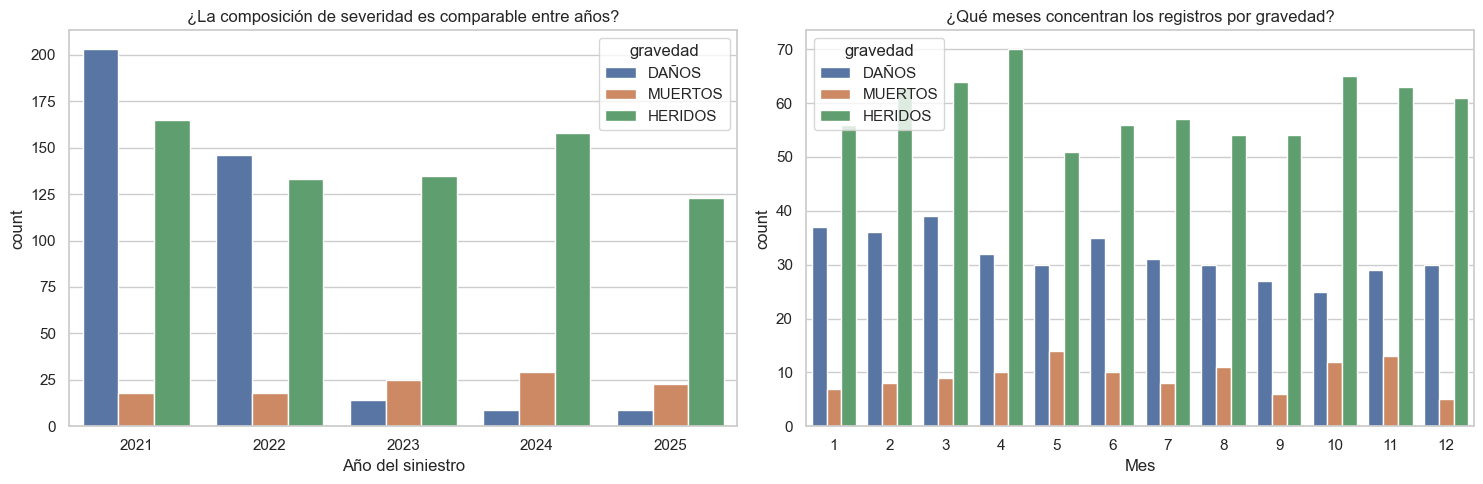

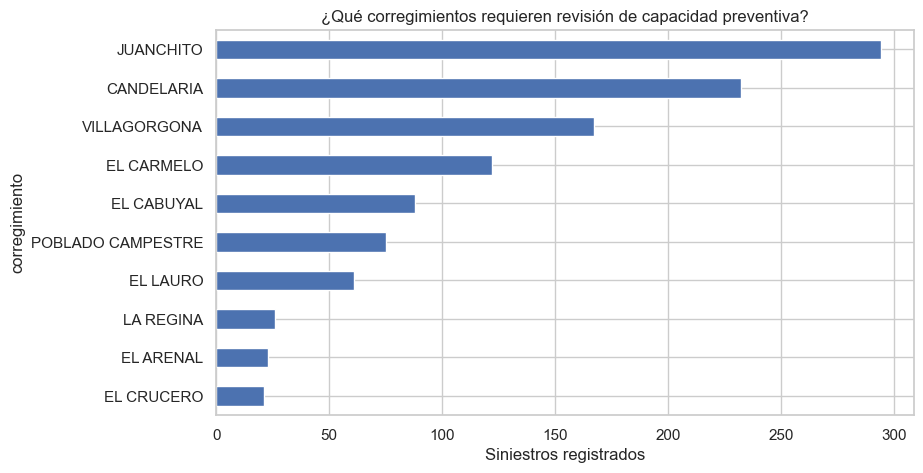

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.countplot(data=incidents, x="anio", hue="gravedad", ax=axes[0])
axes[0].set_title("¿La composición de severidad es comparable entre años?")
axes[0].set_xlabel("Año del siniestro")
sns.countplot(data=incidents, x="mes", hue="gravedad", ax=axes[1])
axes[1].set_title("¿Qué meses concentran los registros por gravedad?")
axes[1].set_xlabel("Mes")
plt.tight_layout()
plt.show()

top_locations = incidents.corregimiento.value_counts().head(10).sort_values()
ax = top_locations.plot.barh(figsize=(9, 5), title="¿Qué corregimientos requieren revisión de capacidad preventiva?")
ax.set_xlabel("Siniestros registrados")
plt.show()

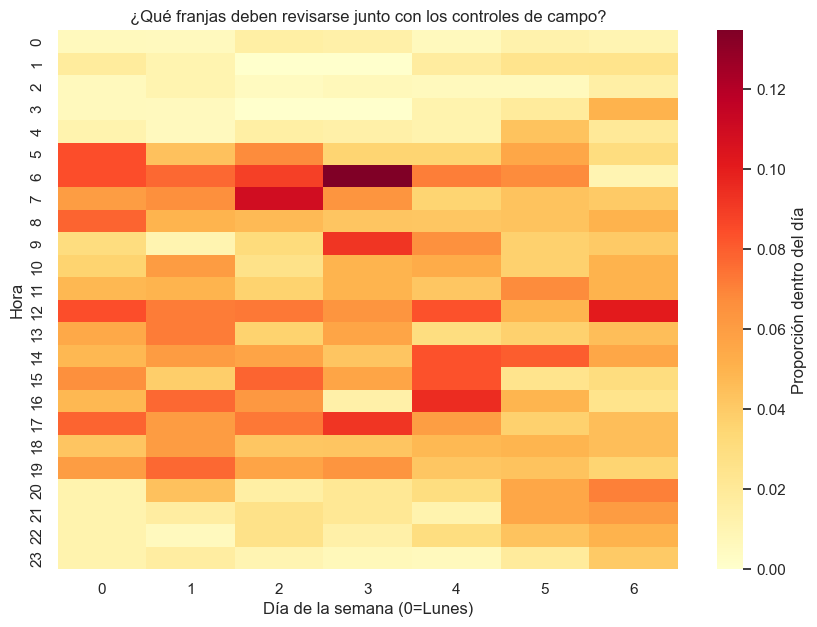

gravedad,DAÑOS,HERIDOS,MUERTOS
anio,,,
2021,0.526,0.427,0.047
2022,0.492,0.448,0.061
2023,0.080,0.776,0.144
2024,0.046,0.806,0.148
2025,0.058,0.794,0.148


In [ ]:
pivot = pd.crosstab(incidents["hora"].astype(int), incidents["dia_semana_num"], normalize="columns")
plt.figure(figsize=(10, 7))
sns.heatmap(pivot, cmap="YlOrRd", cbar_kws={"label": "Proporción dentro del día"})
plt.title("¿Qué franjas deben revisarse junto con los controles de campo?")
plt.xlabel("Día de la semana (0=Lunes)")
plt.ylabel("Hora")
plt.show()

severity_year = pd.crosstab(incidents.anio, incidents.gravedad, normalize="index").round(3)
display(severity_year)

**Hallazgo inesperado a discutir.** Si la proporción de `DAÑOS`, `HERIDOS` o `MUERTOS` cambia abruptamente entre años, no se debe atribuir de inmediato a una mejora o deterioro vial: puede representar un cambio de registro. Por eso la severidad se mantiene como parte del EDA y no como objetivo del problema de clasificación final.

In [ ]:
start, end = incidents.fecha.min().to_period("M"), incidents.fecha.max().to_period("M")
periods = pd.period_range(start, end, freq="M")
locations = pd.DataFrame({"corregimiento": sorted(incidents.corregimiento.unique())})
monthly = locations.merge(pd.DataFrame({"periodo": periods}), how="cross")
monthly["fecha"] = monthly.periodo.dt.to_timestamp()
observed = (incidents.assign(periodo=incidents.fecha.dt.to_period("M"))
            .groupby(["corregimiento", "periodo"], as_index=False).size()
            .rename(columns={"size": "siniestros_mes"}))
monthly = monthly.merge(observed, on=["corregimiento", "periodo"], how="left")
monthly["siniestros_mes"] = monthly.siniestros_mes.fillna(0).astype(int)
monthly = monthly.sort_values(["corregimiento", "fecha"]).reset_index(drop=True)
groups = monthly.groupby("corregimiento", observed=True).siniestros_mes
monthly["siniestros_lag_1"] = groups.shift(1).fillna(0)
monthly["promedio_3_meses_previo"] = groups.transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean()).fillna(0)
monthly["anio"] = monthly.fecha.dt.year.astype(int)
monthly["mes"] = monthly.fecha.dt.month.astype(int)
monthly["mes_seno"] = np.sin(2 * np.pi * monthly.mes / 12)
monthly["mes_coseno"] = np.cos(2 * np.pi * monthly.mes / 12)
print(monthly.shape)
monthly.head()

(2160, 10)


,corregimiento,periodo,fecha,siniestros_mes,siniestros_lag_1,promedio_3_meses_previo,anio,mes,mes_seno,mes_coseno
0,BUCHITOLO,2021-01,2021-01-01,0,0.0,0.000000,2021,1,0.500000,8.660254e-01
1,BUCHITOLO,2021-02,2021-02-01,1,0.0,0.000000,2021,2,0.866025,5.000000e-01
2,BUCHITOLO,2021-03,2021-03-01,0,1.0,0.500000,2021,3,1.000000,6.123234e-17
3,BUCHITOLO,2021-04,2021-04-01,0,0.0,0.333333,2021,4,0.866025,-5.000000e-01
4,BUCHITOLO,2021-05,2021-05-01,0,0.0,0.333333,2021,5,0.500000,-8.660254e-01


,count,mean,std,mediana,IQR,min,max,sesgo_skew
siniestros_mes,2160.0,0.559,1.569,0.0,0.000,0.0,17.0,4.407
siniestros_lag_1,2160.0,0.559,1.569,0.0,0.000,0.0,17.0,4.408
promedio_3_meses_previo,2160.0,0.570,1.429,0.0,0.333,0.0,12.0,3.939


,siniestros_mes,siniestros_lag_1,promedio_3_meses_previo,mes
siniestros_mes,1.000,0.685,0.750,-0.011
siniestros_lag_1,0.685,1.000,0.891,-0.006
promedio_3_meses_previo,0.750,0.891,1.000,-0.018
mes,-0.011,-0.006,-0.018,1.000


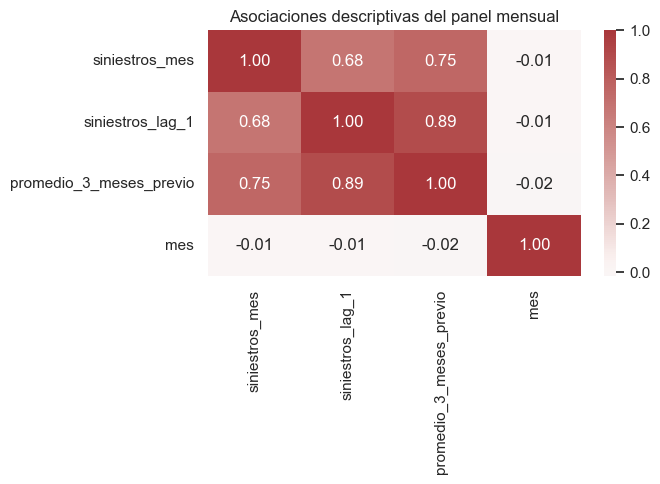

,media,mediana,desviacion,minimo,maximo
corregimiento,,,,,
JUANCHITO,4.900,4.0,3.790,0,14
CANDELARIA,3.867,4.0,3.816,0,17
VILLAGORGONA,2.783,2.5,2.051,0,9
EL CARMELO,2.033,2.0,1.449,0,6
EL CABUYAL,1.467,1.0,1.295,0,5
POBLADO CAMPESTRE,1.250,1.0,1.373,0,5
EL LAURO,1.017,1.0,1.269,0,5
LA REGINA,0.433,0.0,0.909,0,5
EL ARENAL,0.383,0.0,0.666,0,3


In [ ]:
# Pregunta: ¿el conteo tiene muchos ceros, dispersión y asimetría suficientes para
# justificar comparar modelos con una regla de promedio único?
monthly_stats = monthly[["siniestros_mes", "siniestros_lag_1", "promedio_3_meses_previo"]].describe().T
monthly_stats["mediana"] = monthly[["siniestros_mes", "siniestros_lag_1", "promedio_3_meses_previo"]].median()
monthly_stats["IQR"] = (
    monthly[["siniestros_mes", "siniestros_lag_1", "promedio_3_meses_previo"]].quantile(0.75)
    - monthly[["siniestros_mes", "siniestros_lag_1", "promedio_3_meses_previo"]].quantile(0.25)
)
monthly_stats["sesgo_skew"] = monthly[["siniestros_mes", "siniestros_lag_1", "promedio_3_meses_previo"]].skew()
display(monthly_stats[["count", "mean", "std", "mediana", "IQR", "min", "max", "sesgo_skew"]].round(3))

monthly_corr = monthly[["siniestros_mes", "siniestros_lag_1", "promedio_3_meses_previo", "mes"]].corr()
display(monthly_corr.round(3))
plt.figure(figsize=(7, 5))
sns.heatmap(monthly_corr, annot=True, fmt=".2f", center=0, cmap="vlag")
plt.title("Asociaciones descriptivas del panel mensual")
plt.tight_layout()
plt.show()

monthly_summary = monthly.groupby("corregimiento")["siniestros_mes"].agg(
    media="mean", mediana="median", desviacion="std", minimo="min", maximo="max"
).sort_values("media", ascending=False)
display(monthly_summary.round(3))

### Conclusión del análisis mensual

Al consolidar la información por corregimiento y mes obtuvimos 2.160 observaciones. De estas, 1.715 meses, equivalentes al 79,4 %, no registraron siniestros. La mediana fue 0, mientras que el valor máximo fue de 17 siniestros en un mismo corregimiento-mes.

Estos resultados muestran una distribución concentrada en valores bajos, pero con algunos meses que presentan conteos considerablemente mayores. Por esta razón, usar únicamente el promedio histórico del municipio no representa bien las diferencias entre corregimientos ni permite identificar los meses que requieren mayor atención.

También encontramos una asociación positiva entre los siniestros del mes actual y los del mes anterior (correlación de 0,685), así como con el promedio de los tres meses previos (0,750). Esto indica que el comportamiento reciente aporta información útil para priorizar el siguiente mes. Sin embargo, estas asociaciones no demuestran causalidad; únicamente describen patrones históricos disponibles antes del mes objetivo.

## 5. Preparación y partición temporal

La regla más importante del proyecto es no mezclar pasado y futuro. Para cada corregimiento-mes, los lags se calculan solo con meses anteriores. El último año disponible se guarda como prueba final; no se usa para elegir hiperparámetros.

`clase_de_accidente`, `gravedad` y otras consecuencias posteriores al evento se conservan para el EDA, pero no entran en los modelos preventivos. Esto reduce el riesgo de fuga de información.

### IA como revisora crítica — preparación de datos

**Prompt usado:**

> Para dos modelos preventivos a nivel corregimiento-mes —regresión del conteo y clasificación de alta siniestralidad—, ¿qué riesgos de fuga de información debo revisar antes de entrenar? Evalúa especialmente la construcción del umbral y los conteos históricos.

**Crítica sintetizada:** el umbral de la clasificación no puede calcularse usando el año de prueba; los lags deben construirse solo con periodos anteriores; y el conteo del propio mes objetivo no puede entrar como predictor.

**Acción tomada:** los lags usan únicamente meses previos, el último año queda intacto como prueba y el umbral de alta siniestralidad se obtiene exclusivamente del periodo de entrenamiento.

In [ ]:
test_year = int(incidents.anio.max())
inc_train, inc_test = incidents[incidents.anio < test_year].copy(), incidents[incidents.anio == test_year].copy()
mon_train, mon_test = monthly[monthly.anio < test_year].copy(), monthly[monthly.anio == test_year].copy()

positive_train = mon_train.loc[mon_train.siniestros_mes > 0, "siniestros_mes"]
p75_train = float(positive_train.quantile(0.75))
HIGH_THRESHOLD = max(1, int(np.floor(p75_train)) + 1)
mon_train["alta_siniestralidad"] = (mon_train.siniestros_mes >= HIGH_THRESHOLD).astype(int)
mon_test["alta_siniestralidad"] = (mon_test.siniestros_mes >= HIGH_THRESHOLD).astype(int)

print(f"Entrenamiento: hasta {test_year - 1}; prueba: {test_year}")
print("Incidentes train/test:", inc_train.shape, inc_test.shape)
print("Panel mensual train/test:", mon_train.shape, mon_test.shape)
print(f"P75 de meses activos en entrenamiento: {p75_train:.2f}")
print(f"Alta siniestralidad: {HIGH_THRESHOLD} o más siniestros en un mes")
print(mon_train.alta_siniestralidad.value_counts(normalize=True).rename("proporción"))

def preprocessor(categorical, numeric):
    return ColumnTransformer([
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                          ("ohe", OneHotEncoder(handle_unknown="ignore", min_frequency=5))]), categorical),
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                          ("scale", StandardScaler())]), numeric),
    ])

Entrenamiento: hasta 2024; prueba: 2025
Incidentes train/test: (1053, 18) (155, 18)
Panel mensual train/test: (1728, 11) (432, 11)
P75 de meses activos en entrenamiento: 4.00
Alta siniestralidad: 5 o más siniestros en un mes
alta_siniestralidad
0    0.961227
1    0.038773
Name: proporción, dtype: float64


## 6. Problema 1 — estimar el número mensual de siniestros

Comparamos tres algoritmos vistos en clase —regresión lineal, árbol de decisión y Random Forest— contra una referencia simple: asignar a cada caso el promedio histórico del entrenamiento.

La elección del algoritmo no se hace con el año de prueba. Usamos el año inmediatamente anterior como validación temporal para ajustar Árbol y Random Forest; luego hacemos una sola evaluación final sobre el último año.

### IA como revisora crítica — optimización e iteración

**Prompt usado:**

> Si un Random Forest supera al baseline en la prueba temporal, ¿basta con elegirlo? ¿Qué debería hacer para demostrar que la mejora no depende de hiperparámetros escogidos a mano y que no estoy usando el año de prueba para seleccionar el modelo?

**Crítica sintetizada:** no basta con comparar una configuración elegida manualmente; se necesita una validación temporal interna y dejar intacto el año de prueba.

**Acción tomada:** se añadió búsqueda de hiperparámetros sobre años anteriores al año de prueba, usando el año inmediatamente anterior como validación temporal, y se evalúan los parámetros elegidos una sola vez sobre el año de prueba.

In [ ]:
reg_cat = ["corregimiento"]
reg_num = ["anio", "mes", "mes_seno", "mes_coseno", "siniestros_lag_1", "promedio_3_meses_previo"]
reg_features = reg_cat + reg_num
reg_models = {
    "Regresión lineal": LinearRegression(),
    "Árbol de decisión": DecisionTreeRegressor(max_depth=6, min_samples_leaf=8, random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(n_estimators=300, max_depth=10, min_samples_leaf=4,
                                             max_features=0.8, n_jobs=-1, random_state=RANDOM_STATE),
}

baseline_pred = np.repeat(mon_train.siniestros_mes.mean(), len(mon_test))
reg_rows = [{
    "Modelo": "Baseline: promedio histórico",
    "MAE": mean_absolute_error(mon_test.siniestros_mes, baseline_pred),
    "RMSE": mean_squared_error(mon_test.siniestros_mes, baseline_pred) ** 0.5,
    "R2": r2_score(mon_test.siniestros_mes, baseline_pred),
}]

reg_fitted = {}
for name, estimator in reg_models.items():
    pipe = Pipeline([("prep", preprocessor(reg_cat, reg_num)), ("model", estimator)])
    pipe.fit(mon_train[reg_features], mon_train.siniestros_mes)
    pred = pipe.predict(mon_test[reg_features])
    reg_rows.append({"Modelo": name, "MAE": mean_absolute_error(mon_test.siniestros_mes, pred),
                     "RMSE": mean_squared_error(mon_test.siniestros_mes, pred) ** 0.5,
                     "R2": r2_score(mon_test.siniestros_mes, pred)})
    reg_fitted[name] = pipe
reg_results = pd.DataFrame(reg_rows).sort_values("MAE")
display(reg_results.round(4))

reg_val_year = test_year - 1
reg_fit_tune = monthly[monthly.anio < reg_val_year].copy()
reg_val_tune = monthly[monthly.anio == reg_val_year].copy()
reg_search_spaces = {
    "Árbol de decisión": {
        "model__max_depth": [3, 4, 5, 6, 8, 10, None],
        "model__min_samples_leaf": [2, 4, 6, 8, 12, 16],
    },
    "Random Forest": {
        "model__n_estimators": [200, 300, 500],
        "model__max_depth": [5, 8, 10, 12, None],
        "model__min_samples_leaf": [2, 4, 6, 8],
        "model__max_features": [0.5, 0.8, 1.0],
    },
}

tuned_reg = {}
for name in ["Árbol de decisión", "Random Forest"]:
    sampled = list(ParameterSampler(reg_search_spaces[name], n_iter=10, random_state=RANDOM_STATE))
    best_mae, best_params = np.inf, None
    for params in sampled:
        candidate = Pipeline([("prep", preprocessor(reg_cat, reg_num)), ("model", reg_models[name])])
        candidate.set_params(**params)
        candidate.fit(reg_fit_tune[reg_features], reg_fit_tune.siniestros_mes)
        val_pred = candidate.predict(reg_val_tune[reg_features])
        mae = mean_absolute_error(reg_val_tune.siniestros_mes, val_pred)
        if mae < best_mae:
            best_mae, best_params = mae, params
    final_pipe = Pipeline([("prep", preprocessor(reg_cat, reg_num)), ("model", reg_models[name])])
    final_pipe.set_params(**best_params)
    final_pipe.fit(mon_train[reg_features], mon_train.siniestros_mes)
    tuned_reg[name] = final_pipe
    print(f"{name}: mejor validación temporal MAE={best_mae:.4f}; parámetros={best_params}")

tuned_rows = []
for name, pipe in tuned_reg.items():
    pred = pipe.predict(mon_test[reg_features])
    tuned_rows.append({"Modelo optimizado": name,
                       "MAE": mean_absolute_error(mon_test.siniestros_mes, pred),
                       "RMSE": mean_squared_error(mon_test.siniestros_mes, pred) ** 0.5,
                       "R2": r2_score(mon_test.siniestros_mes, pred)})
tuned_reg_results = pd.DataFrame(tuned_rows).sort_values("MAE")
display(tuned_reg_results.round(4))

,Modelo,MAE,RMSE,R2
3,Random Forest,0.4446,0.7931,0.1385
2,Árbol de decisión,0.4598,0.8547,-0.0005
1,Regresión lineal,0.5588,0.9635,-0.2716
0,Baseline: promedio histórico,0.7171,0.8904,-0.0860


Árbol de decisión: mejor validación temporal MAE=0.4308; parámetros={'model__min_samples_leaf': 8, 'model__max_depth': None}


Random Forest: mejor validación temporal MAE=0.4180; parámetros={'model__n_estimators': 500, 'model__min_samples_leaf': 4, 'model__max_features': 0.5, 'model__max_depth': 12}


,Modelo optimizado,MAE,RMSE,R2
1,Random Forest,0.4393,0.7785,0.1699
0,Árbol de decisión,0.4779,0.8804,-0.0617


,corregimiento,fecha,siniestros_mes,prediccion,error_absoluto
2098,VILLAGORGONA,2025-11-01,6,2.24,3.76
2099,VILLAGORGONA,2025-12-01,0,3.33,3.33
2093,VILLAGORGONA,2025-06-01,5,2.05,2.95
2088,VILLAGORGONA,2025-01-01,0,2.87,2.87
1009,JUANCHITO,2025-02-01,0,2.74,2.74
1614,POBLADO CAMPESTRE,2025-07-01,4,1.27,2.73
1013,JUANCHITO,2025-06-01,0,2.72,2.72
228,CANDELARIA,2025-01-01,0,2.60,2.60
479,EL CARMELO,2025-12-01,0,2.53,2.53
2095,VILLAGORGONA,2025-08-01,0,2.52,2.52


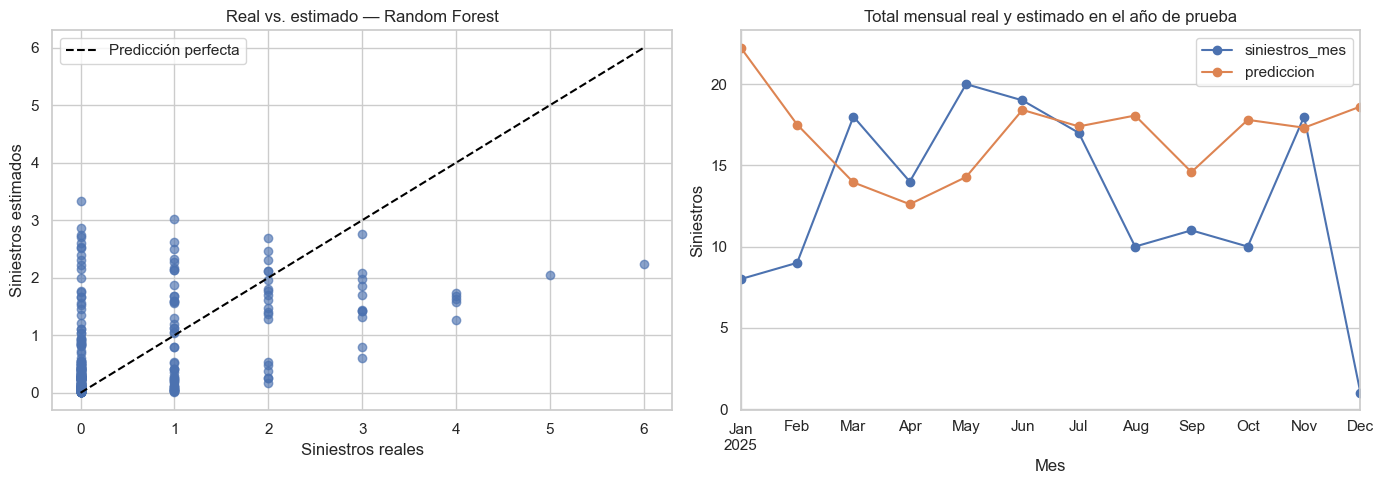

In [ ]:
best_reg_name = tuned_reg_results.iloc[0]["Modelo optimizado"]
best_reg_pipe = tuned_reg[best_reg_name]
best_reg_pred = best_reg_pipe.predict(mon_test[reg_features])

diagnostic = mon_test[["corregimiento", "fecha", "siniestros_mes"]].copy()
diagnostic["prediccion"] = best_reg_pred
diagnostic["error_absoluto"] = (diagnostic["siniestros_mes"] - diagnostic["prediccion"]).abs()
display(diagnostic.sort_values("error_absoluto", ascending=False).head(10).round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(diagnostic["siniestros_mes"], diagnostic["prediccion"], alpha=0.65)
limit = max(diagnostic["siniestros_mes"].max(), diagnostic["prediccion"].max())
axes[0].plot([0, limit], [0, limit], "--", color="black", label="Predicción perfecta")
axes[0].set(title=f"Real vs. estimado — {best_reg_name}", xlabel="Siniestros reales", ylabel="Siniestros estimados")
axes[0].legend()

diagnostic.groupby("fecha")[["siniestros_mes", "prediccion"]].sum().plot(ax=axes[1], marker="o")
axes[1].set(title="Total mensual real y estimado en el año de prueba", xlabel="Mes", ylabel="Siniestros")
plt.tight_layout()
plt.show()

### Conclusión del modelo de regresión

El Random Forest optimizado fue el modelo con mejor desempeño en el año de prueba. Alcanzó un MAE de 0,4393, frente a 0,7171 del baseline basado en el promedio histórico. Esto representa una reducción aproximada del 38,7 % en el error absoluto medio.

El valor de R² fue 0,1699. Aunque el modelo mejora claramente la referencia simple, esta métrica indica que todavía queda una parte importante de la variación sin explicar. La principal razón es que el conjunto no incluye variables como aforo vehicular, clima, obras, velocidad, controles o exposición de peatones y ciclistas.

Concluimos que el modelo puede servir para ordenar una lista de corregimientos que requieren revisión preventiva, pero no para reemplazar una inspección técnica ni para asegurar cuántos siniestros ocurrirán.

### Conclusión de la comparación de modelos

La comparación con el baseline confirma que el Random Forest aporta valor para la estimación mensual: disminuye el MAE de 0,7171 a 0,4393. Los demás modelos no lograron superar ese desempeño en el año de prueba.

Por otro lado, el modelo de clasificación logró ordenar los casos con un AUC-ROC alto, pero no detectó los meses de alta siniestralidad usando el umbral de decisión evaluado en el test. La clase ALTA es muy poco frecuente y el modelo no tuvo suficiente evidencia para activar alertas sin generar un riesgo importante de falsas alarmas.

Por esta razón, la aplicación se limita a mostrar la estimación mensual de siniestros. La clasificación queda como un análisis exploratorio del proyecto y no como una alerta operativa hasta contar con más datos y variables explicativas.

## 7. Problema 2 — clasificar alta siniestralidad mensual

La segunda pregunta usa la misma unidad de análisis: corregimiento-mes. Definimos `alta_siniestralidad` cuando el conteo alcanza el umbral calculado **solo con entrenamiento**. El umbral no es una frontera natural de seguridad; es una regla operativa que permite priorizar capacidad preventiva.

Comparamos regresión logística, árbol de decisión y Random Forest. Reportamos Accuracy, Precision, Recall, F1, AUC-ROC y AUC-PR porque una sola métrica puede ser engañosa si la clase positiva es poco frecuente.

,Modelo,Accuracy,Precision,Recall,F1,AUC-ROC,AUC-PR
1,Regresión logística,0.9676,0.0000,0.0,0.00,0.9407,0.0549
3,Random Forest,0.9931,0.0000,0.0,0.00,0.9337,0.1842
2,Árbol de decisión,0.9468,0.0435,0.5,0.08,0.7314,0.0478
0,Baseline: clase mayoritaria,0.9954,0.0000,0.0,0.00,0.5000,0.0046


Regresión logística: mejor validación temporal AUC=0.9264; parámetros={'model__C': np.float64(2.2758459260747887)}
Árbol de decisión: mejor validación temporal AUC=0.7938; parámetros={'model__min_samples_leaf': 6, 'model__max_depth': 4}


Random Forest: mejor validación temporal AUC=0.8989; parámetros={'model__n_estimators': 350, 'model__min_samples_leaf': 2, 'model__max_features': 0.5, 'model__max_depth': None}


,Modelo optimizado,Accuracy,Precision,Recall,F1,AUC-ROC,AUC-PR
2,Random Forest,0.9954,0.0000,0.0,0.0000,0.9430,0.2700
0,Regresión logística,0.9560,0.0000,0.0,0.0000,0.9337,0.0490
1,Árbol de decisión,0.9051,0.0244,0.5,0.0465,0.7145,0.0478


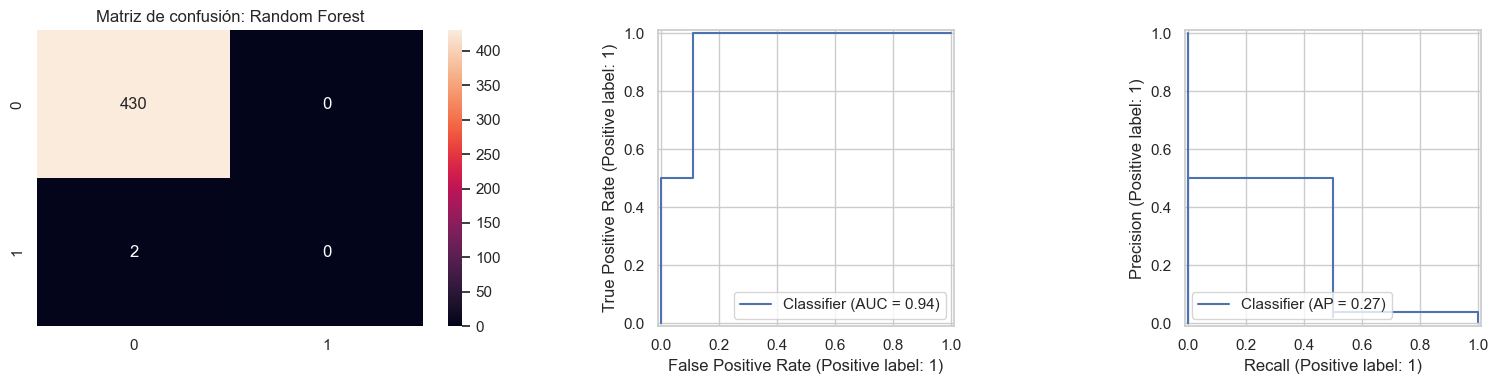

In [ ]:
clf_cat = ["corregimiento"]
clf_num = ["anio", "mes", "mes_seno", "mes_coseno", "siniestros_lag_1", "promedio_3_meses_previo"]
clf_features = clf_cat + clf_num
clf_models = {
    "Regresión logística": LogisticRegression(C=0.5, class_weight="balanced", max_iter=2000,
                                                solver="liblinear", random_state=RANDOM_STATE),
    "Árbol de decisión": DecisionTreeClassifier(max_depth=6, min_samples_leaf=8,
                                                 class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=350, max_depth=12, min_samples_leaf=4,
                                              max_features=0.8, class_weight="balanced_subsample",
                                              n_jobs=-1, random_state=RANDOM_STATE),
}

train_prevalence = mon_train.alta_siniestralidad.mean()
baseline_proba = np.repeat(train_prevalence, len(mon_test))
baseline_label = (baseline_proba >= 0.5).astype(int)
clf_rows = [{
    "Modelo": "Baseline: clase mayoritaria",
    "Accuracy": accuracy_score(mon_test.alta_siniestralidad, baseline_label),
    "Precision": precision_score(mon_test.alta_siniestralidad, baseline_label, zero_division=0),
    "Recall": recall_score(mon_test.alta_siniestralidad, baseline_label, zero_division=0),
    "F1": f1_score(mon_test.alta_siniestralidad, baseline_label, zero_division=0),
    "AUC-ROC": roc_auc_score(mon_test.alta_siniestralidad, baseline_proba),
    "AUC-PR": average_precision_score(mon_test.alta_siniestralidad, baseline_proba),
}]

clf_fitted = {}
for name, estimator in clf_models.items():
    pipe = Pipeline([("prep", preprocessor(clf_cat, clf_num)), ("model", estimator)])
    pipe.fit(mon_train[clf_features], mon_train.alta_siniestralidad)
    proba = pipe.predict_proba(mon_test[clf_features])[:, 1]
    label = (proba >= 0.5).astype(int)
    clf_rows.append({"Modelo": name, "Accuracy": accuracy_score(mon_test.alta_siniestralidad, label),
                     "Precision": precision_score(mon_test.alta_siniestralidad, label, zero_division=0),
                     "Recall": recall_score(mon_test.alta_siniestralidad, label, zero_division=0),
                     "F1": f1_score(mon_test.alta_siniestralidad, label, zero_division=0),
                     "AUC-ROC": roc_auc_score(mon_test.alta_siniestralidad, proba),
                     "AUC-PR": average_precision_score(mon_test.alta_siniestralidad, proba)})
    clf_fitted[name] = pipe
clf_results = pd.DataFrame(clf_rows).sort_values("AUC-ROC", ascending=False)
display(clf_results.round(4))

clf_val_year = test_year - 1
clf_fit_tune = monthly[monthly.anio < clf_val_year].copy()
clf_val_tune = monthly[monthly.anio == clf_val_year].copy()
clf_fit_tune["alta_siniestralidad"] = (clf_fit_tune.siniestros_mes >= HIGH_THRESHOLD).astype(int)
clf_val_tune["alta_siniestralidad"] = (clf_val_tune.siniestros_mes >= HIGH_THRESHOLD).astype(int)
clf_spaces = {
    "Regresión logística": {"model__C": np.logspace(-2, 1, 15)},
    "Árbol de decisión": {
        "model__max_depth": [3, 4, 5, 6, 8, 10],
        "model__min_samples_leaf": [2, 4, 6, 8, 12, 16],
    },
    "Random Forest": {
        "model__n_estimators": [200, 350, 500],
        "model__max_depth": [6, 8, 12, 16, None],
        "model__min_samples_leaf": [2, 4, 6, 8],
        "model__max_features": [0.5, 0.8, 1.0],
    },
}

tuned_clf = {}
for name in ["Regresión logística", "Árbol de decisión", "Random Forest"]:
    sampled = list(ParameterSampler(clf_spaces[name], n_iter=10, random_state=RANDOM_STATE))
    best_auc, best_params = -np.inf, None
    for params in sampled:
        candidate = Pipeline([("prep", preprocessor(clf_cat, clf_num)), ("model", clf_models[name])])
        candidate.set_params(**params)
        candidate.fit(clf_fit_tune[clf_features], clf_fit_tune.alta_siniestralidad)
        val_proba = candidate.predict_proba(clf_val_tune[clf_features])[:, 1]
        auc = roc_auc_score(clf_val_tune.alta_siniestralidad, val_proba)
        if auc > best_auc:
            best_auc, best_params = auc, params
    final_pipe = Pipeline([("prep", preprocessor(clf_cat, clf_num)), ("model", clf_models[name])])
    final_pipe.set_params(**best_params)
    final_pipe.fit(mon_train[clf_features], mon_train.alta_siniestralidad)
    tuned_clf[name] = final_pipe
    print(f"{name}: mejor validación temporal AUC={best_auc:.4f}; parámetros={best_params}")

optimized_clf_rows = []
for name, pipe in tuned_clf.items():
    proba = pipe.predict_proba(mon_test[clf_features])[:, 1]
    label = (proba >= 0.5).astype(int)
    optimized_clf_rows.append({"Modelo optimizado": name,
        "Accuracy": accuracy_score(mon_test.alta_siniestralidad, label),
        "Precision": precision_score(mon_test.alta_siniestralidad, label, zero_division=0),
        "Recall": recall_score(mon_test.alta_siniestralidad, label, zero_division=0),
        "F1": f1_score(mon_test.alta_siniestralidad, label, zero_division=0),
        "AUC-ROC": roc_auc_score(mon_test.alta_siniestralidad, proba),
        "AUC-PR": average_precision_score(mon_test.alta_siniestralidad, proba)})
optimized_clf_results = pd.DataFrame(optimized_clf_rows).sort_values("AUC-ROC", ascending=False)
display(optimized_clf_results.round(4))

best_clf_name = optimized_clf_results.iloc[0]["Modelo optimizado"]
best_pipe = tuned_clf[best_clf_name]
best_proba = best_pipe.predict_proba(mon_test[clf_features])[:, 1]
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.heatmap(confusion_matrix(mon_test.alta_siniestralidad, best_proba >= .5), annot=True, fmt="d", ax=axes[0])
axes[0].set_title(f"Matriz de confusión: {best_clf_name}")
RocCurveDisplay.from_predictions(mon_test.alta_siniestralidad, best_proba, ax=axes[1])
PrecisionRecallDisplay.from_predictions(mon_test.alta_siniestralidad, best_proba, ax=axes[2])
plt.tight_layout()
plt.show()

## 8. Cómo decidimos si el clasificador sirve

**Prompt usado:**

> Para clasificar si el próximo mes tendrá alta siniestralidad por corregimiento, definimos el umbral usando solo entrenamiento y comparamos regresión logística, árbol y Random Forest. ¿Qué debo revisar antes de aceptar un AUC alto como evidencia de utilidad operativa?

**Qué conservamos de la crítica:** un AUC alto no corrige subregistro, cambio temporal ni desbalance. Por eso miramos matriz de confusión, precision, recall, F1, AUC-ROC y AUC-PR; además verificamos que el umbral sea explicable para el stakeholder.

**Regla de decisión del equipo:** solo presentaremos la alerta como parte de la aplicación si mejora al baseline en el último año y no tiene un recall tan bajo que deje fuera la mayoría de meses realmente altos. Si no cumple, queda como análisis académico y la app mantiene únicamente la estimación mensual.

## 9. Ética, sesgos y limitaciones

- Los datos reflejan lo que se registra; no equivalen necesariamente a todos los siniestros.
- Una mayor frecuencia registrada puede reflejar mejor reporte o vigilancia, no mayor riesgo real.
- Los corregimientos pueden correlacionarse con desigualdad de infraestructura y vigilancia. El producto debe asignar **apoyo preventivo**, nunca justificar estigmas, sanciones individuales o controles discriminatorios.
- El umbral de alta siniestralidad es una regla operativa basada en la distribución histórica del entrenamiento; no es una frontera natural ni causal.
- Los lags requieren que la entidad actualice los conteos mensuales antes de usar la app.
- La herramienta no descubre causas ni responsabilidad: una inspección técnica y participación local son indispensables.

### Aplicación web: alcance real

La aplicación actual se concentra en el problema que sí se puede explicar de forma directa al usuario: **la estimación mensual de siniestros por corregimiento**. Muestra el resultado, los datos recientes que lo alimentan, acciones sugeridas y una advertencia de límites.

El clasificador de alta siniestralidad queda documentado y evaluado en este cuaderno. Solo debe agregarse a la aplicación si pasa la regla de utilidad definida en la sección anterior. Esta separación es intencional: preferimos una app sencilla y defendible antes que una app con una alerta que no podamos justificar.

## 10. Conclusiones y trabajo futuro

Este proyecto no pretende decir que un corregimiento es peligroso ni explicar la causa de un siniestro. Propone una forma reproducible de ordenar la revisión preventiva del mes siguiente usando información histórica disponible.

La principal evidencia será la comparación temporal contra el baseline. Si la mejora es pequeña o inestable, nuestra recomendación será mantener un tablero descriptivo y no vender una predicción como una certeza.

Para mejorar el trabajo necesitaríamos aforos y exposición vial, clima, obras, velocidad, controles, geometría de las vías y validación con el equipo territorial. En una segunda fase mediríamos si las intervenciones priorizadas reducen incidentes, en lugar de medir únicamente la exactitud del modelo.